In [4]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, accuracy_score
)
from sklearn.calibration import calibration_curve

In [5]:
# Load balanced training and test sets
X_train_res, y_train_res = joblib.load("X_train_balanced.pkl")
X_test, y_test           = joblib.load("X_test_balanced.pkl")
class_names              = joblib.load("class_names.pkl")

Train XGBoost

In [6]:
# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_res, y_train_res)

# Save model
joblib.dump(xgb_model, "xgboost.pkl")
print("✅ XGBoost model trained and saved as xgboost.pkl")

c:\Users\Yaswanth\Downloads\diatom-classification\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [14:49:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost model trained and saved as xgboost.pkl


Explanation:
We configure XGBoost with 200 trees, moderate depth, and subsampling for regularization. The model is saved for reuse.


Confusion Matrix

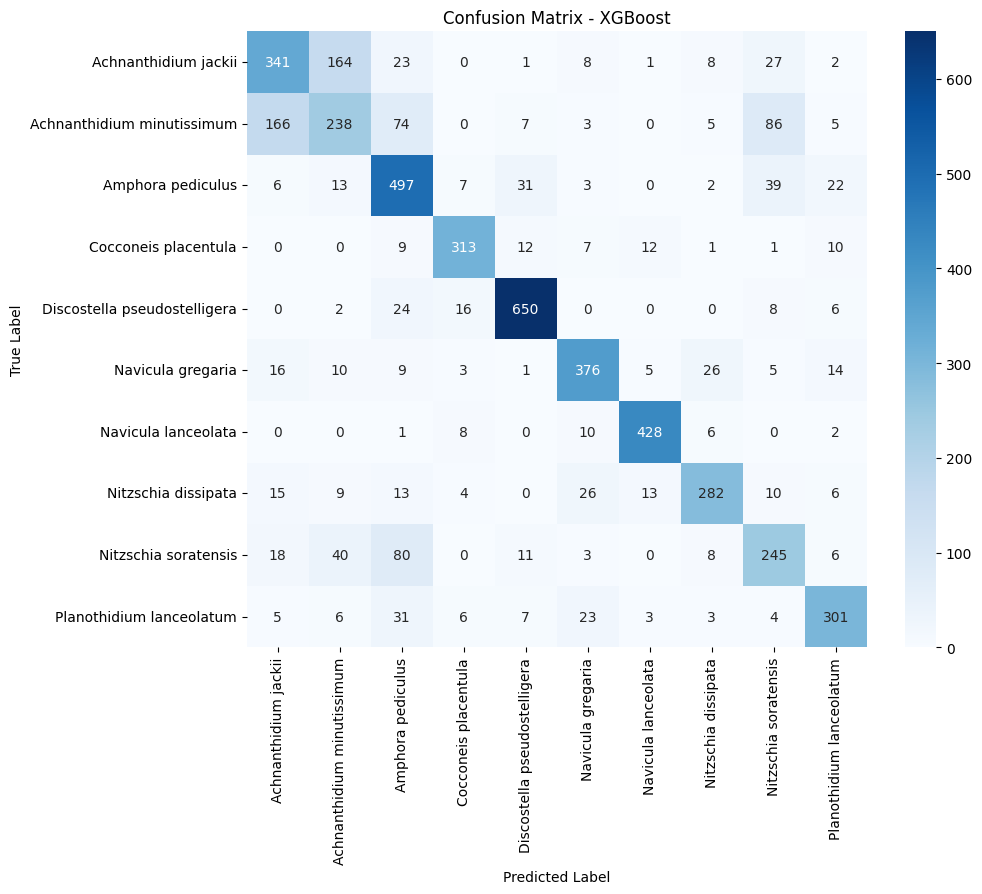

In [7]:
y_pred = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

Explanation:
Shows per-class predictions vs true labels, highlighting misclassifications


ROC Macro

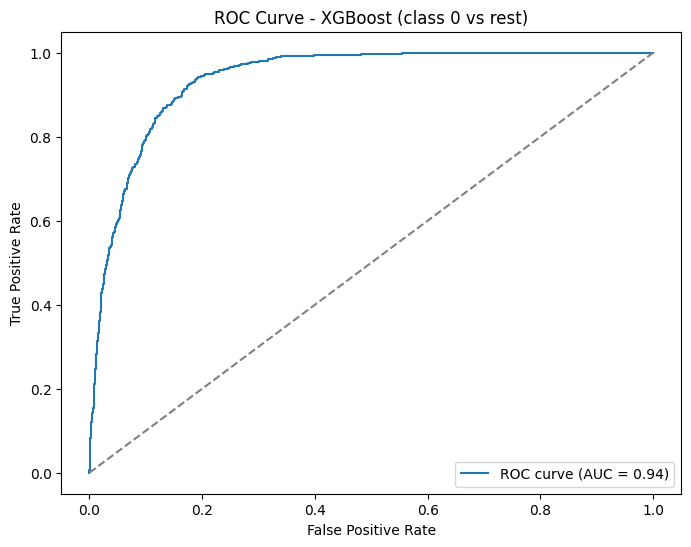

In [10]:
y_prob = xgb_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve((y_test == 0).astype(int), y_prob[:,0], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (class 0 vs rest)")
plt.legend()
plt.show()

Explanation:
For multi-class, you can plot ROC curves one-vs-rest. Here we show class 0 vs all others as an example.


Precision-Recall

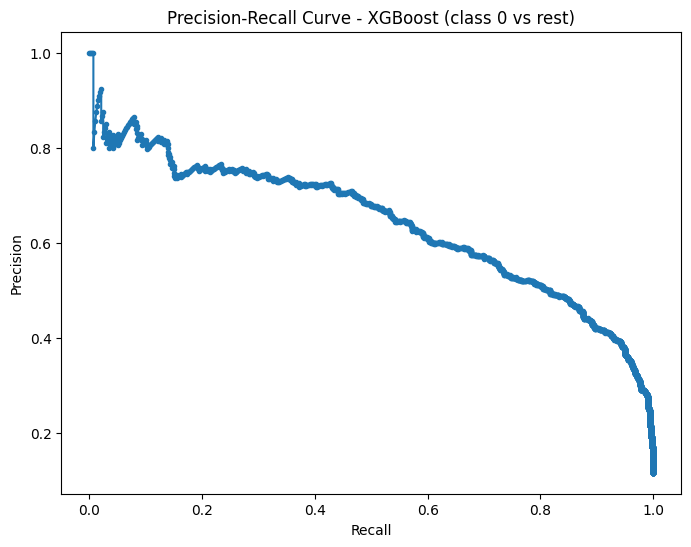

In [11]:
precision, recall, thresholds = precision_recall_curve((y_test == 0).astype(int), y_prob[:,0])

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost (class 0 vs rest)")
plt.show()

Explanation:
Shows trade-off between precision and recall for one class. You can loop over all classes if needed.




Confidence Distribution

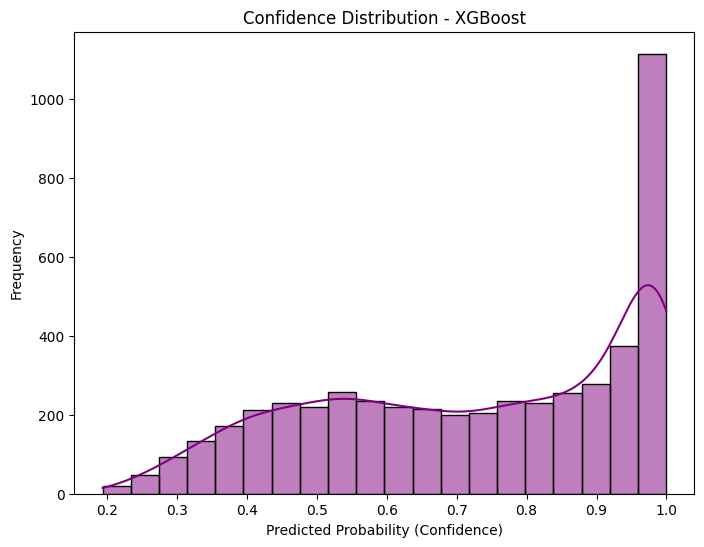

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(np.max(y_prob, axis=1), bins=20, kde=True, color="purple")
plt.xlabel("Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.title("Confidence Distribution - XGBoost")
plt.show()

Class Wise accuracy

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_24432\1222169649.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_acc, palette="viridis")


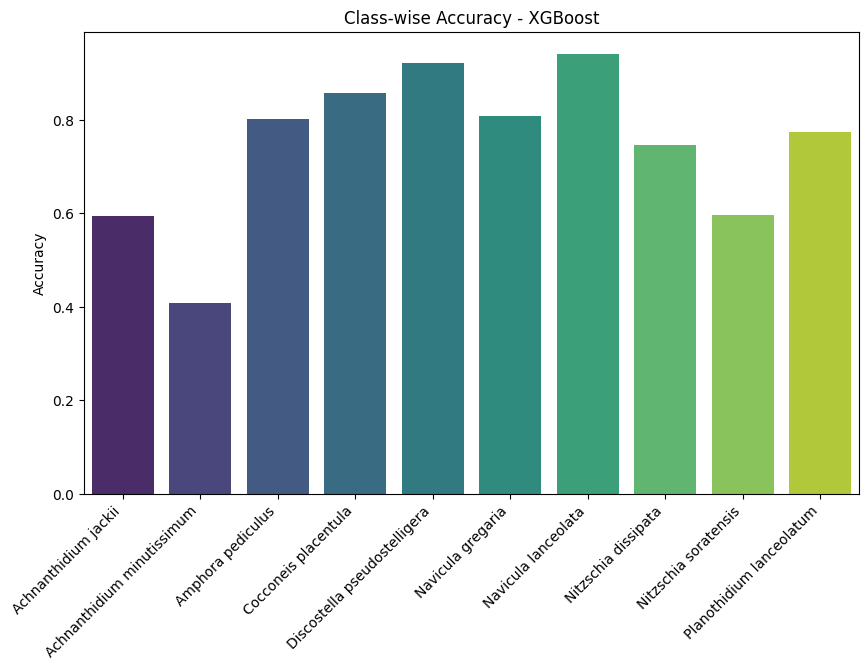

In [13]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
class_acc = [report[cls]['recall'] for cls in class_names]

plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_acc, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy - XGBoost")
plt.show()

Explanation:
Plots recall (accuracy per class) to see which species are classified well


Reliability plot

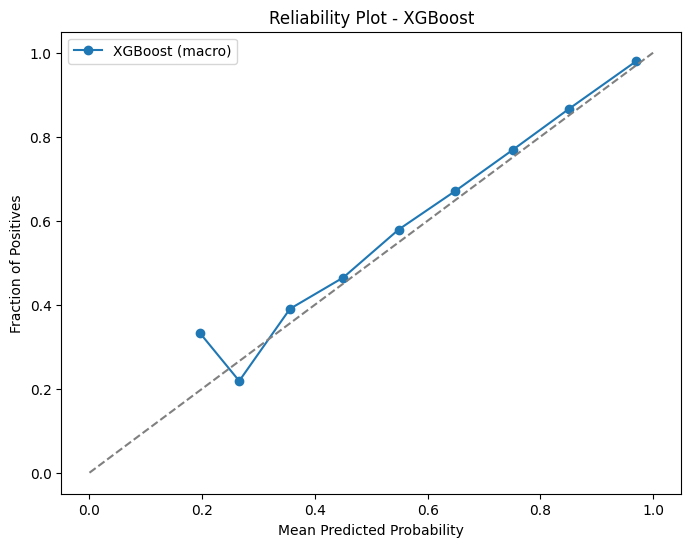

In [14]:
correct = (y_pred == y_test).astype(int)
confidence = np.max(y_prob, axis=1)

prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label="XGBoost (macro)")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Plot - XGBoost")
plt.legend()
plt.show()

Explanation:
Shows how well predicted probabilities match actual correctness overall.


In [15]:
import joblib
from sklearn.metrics import classification_report, accuracy_score

# Load model and supporting data
xgb_model     = joblib.load("xgboost.pkl")
X_test, y_test = joblib.load("X_test_balanced.pkl")
class_names   = joblib.load("class_names.pkl")

# Predict on test set
y_pred = xgb_model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

XGBoost Accuracy: 0.7419

Classification Report:
                              precision    recall  f1-score   support

        Achnanthidium jackii       0.60      0.59      0.60       575
  Achnanthidium minutissimum       0.49      0.41      0.45       584
           Amphora pediculus       0.65      0.80      0.72       620
        Cocconeis placentula       0.88      0.86      0.87       365
Discostella pseudostelligera       0.90      0.92      0.91       706
           Navicula gregaria       0.82      0.81      0.81       465
         Navicula lanceolata       0.93      0.94      0.93       455
         Nitzschia dissipata       0.83      0.75      0.78       378
        Nitzschia soratensis       0.58      0.60      0.59       411
    Planothidium lanceolatum       0.80      0.77      0.79       389

                    accuracy                           0.74      4948
                   macro avg       0.75      0.74      0.74      4948
                weighted avg       0.74

✅ Workflow Summary
- Trains XGBoost with regularization and subsampling.
- Saves model as xgboost.pkl.
- Evaluates with confusion matrix, ROC, PR curve, confidence distribution, class-wise accuracy, and reliability plot.
- Provides both per-class and macro-level insights.
